In [8]:
from ast import literal_eval
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def parse_metric(value):
    normalized = re.sub(
        r"np\.float(?:16|32|64)\(([-+0-9.eE]+)\)", r"\1", value
    )
    return literal_eval(normalized)


csv_name = "pend_discrete_rmse_results.csv"
csv_candidates = [
    Path(csv_name),
    Path("dissertation") / csv_name,
    Path("..") / csv_name,
]
csv_path = next(path for path in csv_candidates if path.exists())
results = pd.read_csv(csv_path)

summary_columns = [
    "training_episodes",
    "rmse_dimension_1_mean",
    "rmse_dimension_1_standard_error",
    "rmse_dimension_2_mean",
    "rmse_dimension_2_standard_error",
    "r2_dimension_1_mean",
    "r2_dimension_1_standard_error",
    "r2_dimension_2_mean",
    "r2_dimension_2_standard_error",
    "eval_time_mean",
    "eval_time_standard_error",
    "fit_time_mean",
    "fit_time_standard_error",
]

if results.empty:
    summary = pd.DataFrame(columns=summary_columns)
    print(f"No completed iterations found in {csv_path}")
else:
    metric_columns = [
        "rmse_dimension_1",
        "rmse_dimension_2",
        "r2_dimension_1",
        "r2_dimension_2",
        "eval_times",
        "fit_times",
    ]
    missing_columns = [column for column in metric_columns if column not in results.columns]
    if missing_columns:
        raise ValueError(
            "CSV is not in the required dimension-specific format. "
            f"Missing columns: {missing_columns}. Found: {list(results.columns)}"
        )

    metric_arrays = {
        column: np.asarray(results[column].map(parse_metric).tolist(), dtype=float)
        for column in metric_columns
    }

    for column, values in metric_arrays.items():
        if values.ndim == 1:
            metric_arrays[column] = values.reshape(1, -1)

    shapes = {column: values.shape for column, values in metric_arrays.items()}
    if len(set(shapes.values())) != 1:
        raise ValueError(f"Metric array shapes do not match: {shapes}")

    training_episodes = np.array([3, 9, 27, 60, 100])
    n_iterations, n_training_sizes = metric_arrays["rmse_dimension_1"].shape
    if n_training_sizes != len(training_episodes):
        raise ValueError(
            f"Expected {len(training_episodes)} result columns, got {n_training_sizes}"
        )

    standard_errors = {}
    for column, values in metric_arrays.items():
        if n_iterations > 1:
            standard_errors[column] = values.std(axis=0, ddof=1) / np.sqrt(n_iterations)
        else:
            standard_errors[column] = np.full(n_training_sizes, np.nan)

    summary = pd.DataFrame(
        {
            "training_episodes": training_episodes,
            "rmse_dimension_1_mean": metric_arrays["rmse_dimension_1"].mean(axis=0),
            "rmse_dimension_1_standard_error": standard_errors["rmse_dimension_1"],
            "rmse_dimension_2_mean": metric_arrays["rmse_dimension_2"].mean(axis=0),
            "rmse_dimension_2_standard_error": standard_errors["rmse_dimension_2"],
            "r2_dimension_1_mean": metric_arrays["r2_dimension_1"].mean(axis=0),
            "r2_dimension_1_standard_error": standard_errors["r2_dimension_1"],
            "r2_dimension_2_mean": metric_arrays["r2_dimension_2"].mean(axis=0),
            "r2_dimension_2_standard_error": standard_errors["r2_dimension_2"],
            "eval_time_mean": metric_arrays["eval_times"].mean(axis=0),
            "eval_time_standard_error": standard_errors["eval_times"],
            "fit_time_mean": metric_arrays["fit_times"].mean(axis=0),
            "fit_time_standard_error": standard_errors["fit_times"],
        }
    )
    print(f"Read {n_iterations} iterations from {csv_path}")

summary

Read 10 iterations from ..\pend_discrete_rmse_results.csv


,training_episodes,rmse_dimension_1_mean,rmse_dimension_1_standard_error,rmse_dimension_2_mean,rmse_dimension_2_standard_error,r2_dimension_1_mean,r2_dimension_1_standard_error,r2_dimension_2_mean,r2_dimension_2_standard_error,eval_time_mean,eval_time_standard_error,fit_time_mean,fit_time_standard_error
0,3,0.514965,0.061910,665.769761,552.877904,0.538001,0.104034,-3.255993e+05,3.187934e+05,17.576263,4.420247,1.548773,0.225292
1,9,0.320948,0.019561,1.282959,0.092664,0.835830,0.021221,8.249098e-01,2.307198e-02,41.956288,9.759046,4.670133,1.128723
2,27,0.289209,0.020363,1008.079788,1006.374877,0.866477,0.021229,-1.065198e+06,1.065198e+06,115.324753,30.036420,19.738706,8.743458
3,60,0.285913,0.018731,2.753915,1.232266,0.869674,0.017876,-1.133477e+00,1.365288e+00,253.805743,64.943914,43.992478,18.371006
4,100,0.278218,0.010589,1.001120,0.036763,0.879200,0.010352,8.964275e-01,7.947902e-03,313.986459,3.929944,42.586037,7.976739


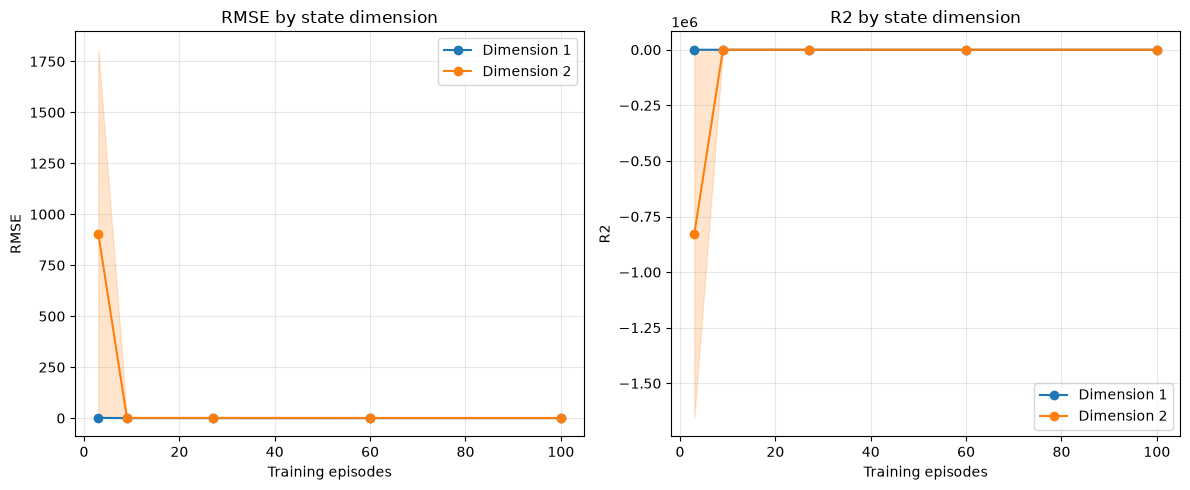

In [7]:
if not summary.empty:
    figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    metric_specs = [
        (
            axes[0],
            "RMSE by state dimension",
            "RMSE",
            ["rmse_dimension_1", "rmse_dimension_2"],
        ),
        (
            axes[1],
            "R2 by state dimension",
            "R2",
            ["r2_dimension_1", "r2_dimension_2"],
        ),
    ]

    for axis, title, ylabel, dimensions in metric_specs:
        for dimension_number, dimension in enumerate(dimensions, start=1):
            mean = summary[f"{dimension}_mean"]
            standard_error = summary[f"{dimension}_standard_error"]
            color = f"C{dimension_number - 1}"
            axis.plot(
                summary["training_episodes"],
                mean,
                marker="o",
                color=color,
                label=f"Dimension {dimension_number}",
            )
            axis.fill_between(
                summary["training_episodes"],
                mean - standard_error,
                mean + standard_error,
                color=color,
                alpha=0.2,
            )

        axis.set_title(title)
        axis.set_xlabel("Training episodes")
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        axis.legend()

    figure.tight_layout()
    plt.show()